<a href="https://colab.research.google.com/github/mkt2004/Advanced-Data-Science-Sign_Language_Model/blob/main/Sign_Language_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Data Science PBL 1 (Group 1)
Teng Wen Jie Sumiko, Yungi Jeong, Andrew Siu, Marley Thrift, Taiga

In [ ]:
# Required for the purposes of running d2l in this environment.
# May cause you to restart your runtime
!pip install setuptools==65.5.0 "wheel<0.40.0"
!pip install d2l==1.0.0a0

  Using cached d2l-1.0.0a0-py3-none-any.whl.metadata (366 bytes)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyterlab-4.6.3-py3-none-any.whl.metadata (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.9/92.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.2 MB/s eta 0:00:00


In [ ]:
import os
import csv
import random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
from d2l import torch as d2l
from torch import nn
from torch.nn import functional as F


## Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive')

In [ ]:
train_path= './SignLanguageDataset/sign_mnist_train.csv'
test_path = './SignLanguageDataset/sign_mnist_test.csv'

label_dict = {
    0:'A' , 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I',10:'K',11:'L',12:'M',
    13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y'
}

In [ ]:
def get_data(file_path):
    with open(file_path) as file:
        data = csv.reader(file)
        labels = []
        images = []
        for i, row in enumerate(data):
            if i == 0:
                continue
            labels.append(row[0])
            image = row[1:]
            image_array = np.array_split(image, 28)
            images.append(image_array)
    return np.array(images).astype(float), np.array(labels).astype(float)

In [ ]:
#Checking the structure of data
data = pd.read_csv(train_path)
data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
#Checking the max and min values
print(data.iloc[:,1])
print(max(data.iloc[:,1]))
print(min(data.iloc[:,1]))

0        107
1        155
2        187
3        211
4        164
        ... 
27450    189
27451    151
27452    174
27453    177
27454    179
Name: pixel1, Length: 27455, dtype: int64
255
0


In [ ]:
train_images, train_labels = get_data(train_path)
test_images, test_labels = get_data(test_path)

split = 0.8
train_split = int(split*len(train_labels))
validation_images = train_images[train_split:]
validation_labels = train_labels[train_split:]
train_images = train_images[:train_split]
train_labels = train_labels[:train_split]

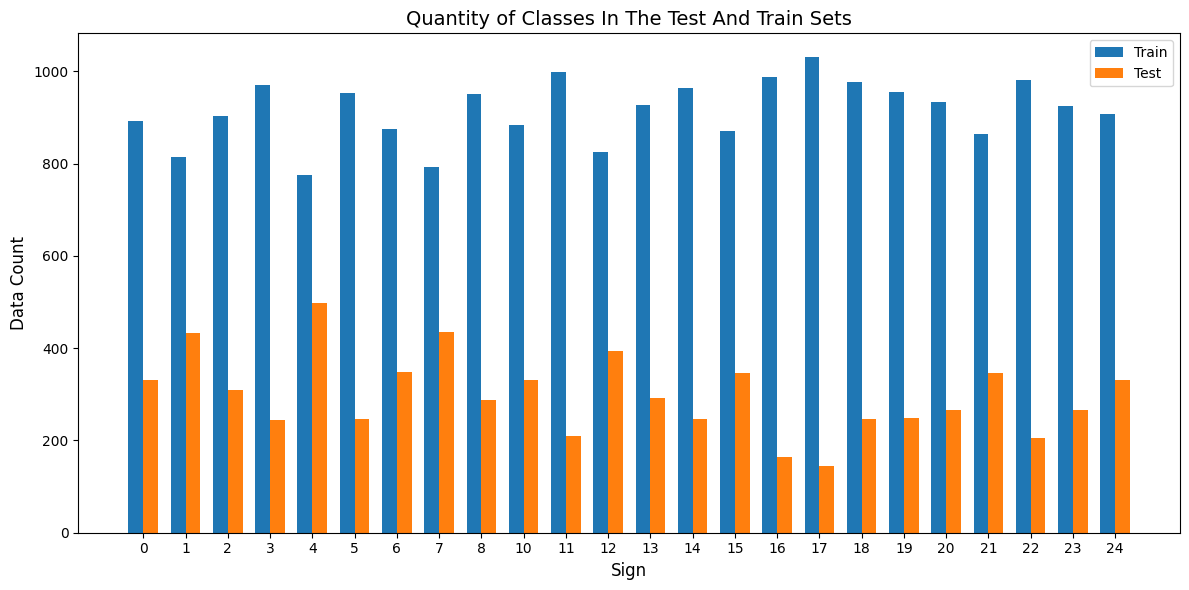

In [ ]:
def counter(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return list(unique.astype(int)), list(counts)

unique_train, counts_train = counter(train_labels)
unique_test, counts_test = counter(test_labels)

x = np.arange(len(unique_train))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
test = ax.bar(x - width/2, counts_train, width, label='Train')
train = ax.bar(x + width/2, counts_test, width, label='Test')

ax.set_ylabel('Data Count', fontsize=12)
ax.set_xlabel('Sign', fontsize=12)
ax.set_title('Quantity of Classes In The Test And Train Sets', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(unique_train)
ax.legend()

fig.tight_layout()

plt.show()

TAKE NOTE: label number 9 is missing because of there is no sign for "J"

In [ ]:
print(train_images.shape,
      train_labels.shape,
      validation_images.shape,
      validation_labels.shape,
      test_images.shape,
      test_labels.shape)

(21964, 28, 28) (21964,) (5491, 28, 28) (5491,) (7172, 28, 28) (7172,)


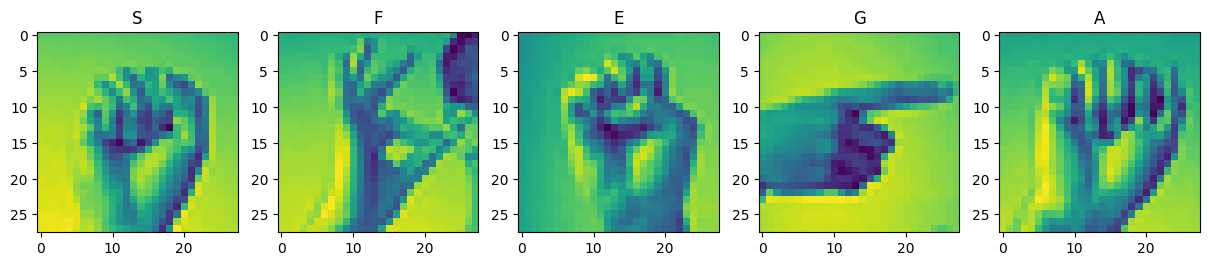

In [ ]:
rand_nums   = [random.randint(0,len(train_images)) for i in range (5)]
rand_imgs   = [train_images[i] for i in rand_nums]
rand_labels = [label_dict[train_labels[i]] for i in rand_nums]

fig, axis=plt.subplots(1,5,figsize=(15,5))
for ax, img, label in zip(axis, rand_imgs, rand_labels):
    ax.imshow(img)
    ax.set_title(label)
plt.show()

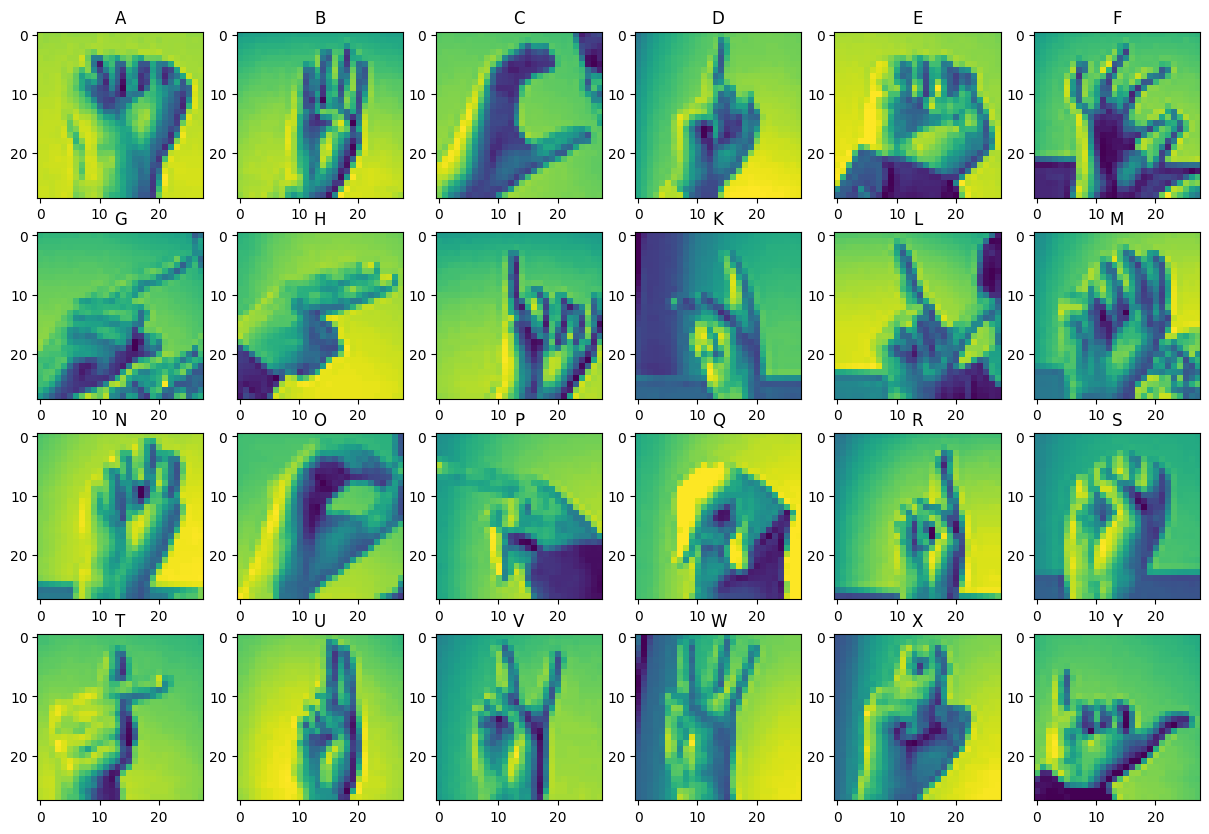

In [ ]:
unique_labels, unique_indices = np.unique(train_labels, return_index=True)
sorted_indices = unique_indices[np.argsort(unique_labels)]
unique_imgs   = [train_images[i] for i in sorted_indices]
unique_labs = [label_dict[train_labels[i]] for i in sorted_indices]

fig, axis = plt.subplots(4, 6, figsize=(15, 10))

axis = axis.flatten()
if len(rand_imgs) == 1:
    axis = [axis]

for ax, img, label in zip(axis, unique_imgs, unique_labs):
    ax.imshow(img)
    ax.set_title(label)
plt.show()


Data augmentation strategy
- Some hands are displaced from center. This means that adding augmentations like image shift may help to artificially increase our dataset by simulating these shifts.

- Same hand gestures may look different by the angle so adding a rotation augmentation might be a good idea.

- Some of the hands seem bigger than others, using zoom augmentations may also help with training.

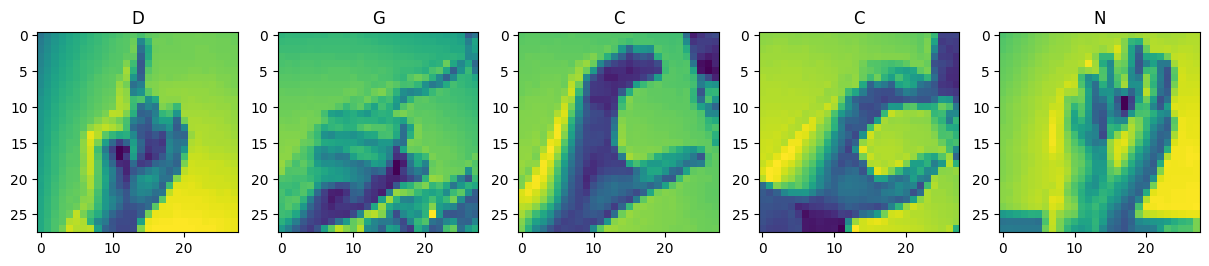

In [ ]:
rand_nums   = range(0,16)
rand_imgs   = [train_images[i] for i in rand_nums]
rand_labels = [label_dict[train_labels[i]] for i in rand_nums]

fig, axis=plt.subplots(1,5,figsize=(15,5))
for ax, img, label in zip(axis, rand_imgs, rand_labels):
    ax.imshow(img)
    ax.set_title(label)
plt.show()

In [ ]:
train_images_tensor = torch.tensor(train_images).unsqueeze(1)
train_labels_tensor = torch.tensor(train_labels)

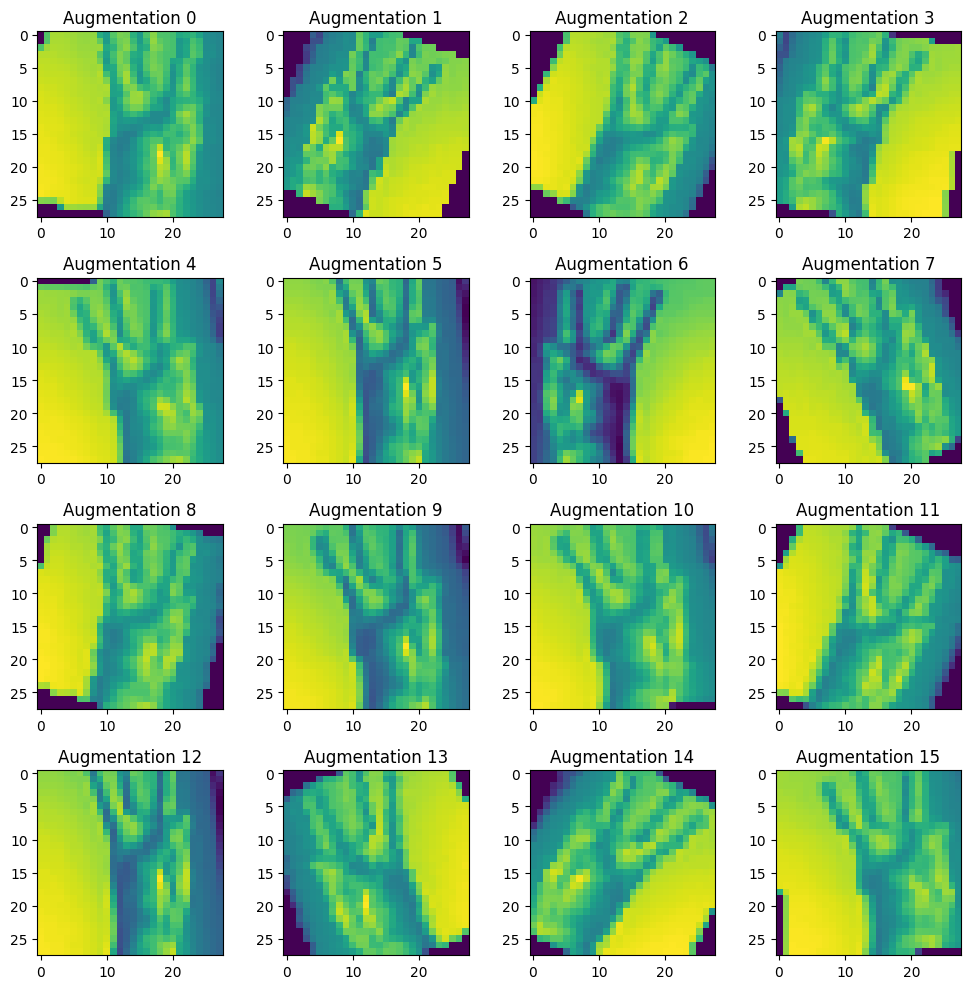

In [ ]:
example_image = train_images_tensor[7:8]
example_label = train_labels_tensor[7].item()

augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(size=(28, 28), scale=(0.8, 1.0)),
])

augmented_images = [augmentations(example_image[0]).unsqueeze(0) for _ in range(16)]
augmented_images = torch.cat(augmented_images)

fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axs.ravel()):
    img = augmented_images[i].squeeze(0).numpy()
    ax.imshow(img)
    ax.set_title(f"Augmentation {i}")

plt.tight_layout()
plt.show()

Data loading

In [ ]:
transform_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(size=(28, 28), scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

transform_no_augment = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
from PIL import Image
class ASL(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images  # NumPy array of images
        self.labels = labels  # NumPy array of labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Convert image from NumPy array to PIL Image
        image = self.images[idx].reshape(28, 28).astype(np.uint8)  # Assuming 28x28 images
        image = Image.fromarray(image)  # Convert NumPy array to PIL Image

        label = self.labels[idx]

        # Apply transformations (if any)
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor (long dtype)
        label = torch.tensor(label, dtype=torch.long)

        return image, label


In [ ]:
train_dataset = ASL(train_images, train_labels, transform=transform_augment)
validation_dataset = ASL(validation_images, validation_labels, transform=transform_no_augment)
test_dataset = ASL(test_images, test_labels, transform=transform_no_augment)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Fully connected MLP neural network


## Defining the two classifiers

In [ ]:
def softmax(X):
    X_shifted = X - X.max(dim=1, keepdim=True).values
    X_exp = torch.exp(X_shifted)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

In [ ]:
# This fully-connected model's infrastructure is quite simple.
# It simply flattens the inputs and then runs it through the softmax function
class SoftmaxRegressionSimple(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

        self.lr = lr

    def parameters(self):
        return [self.W, self.b]

    def forward(self, X):
        X = X.reshape((-1, self.W.shape[0]))
        return softmax(torch.matmul(X, self.W) + self.b)

    def loss(self, y_hat, y):
        return cross_entropy(y_hat, y)

# This fully-connected model's infrastrucutre is non-linear.
# It has NN that can be seen in its init function
class SoftmaxRegressionNonLinear(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.LazyLinear(2048),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.LazyLinear(num_outputs)
        )

    def forward(self, X):
        forward_pass = self.net(X)
        return softmax(forward_pass)

    def loss(self, y_hat, y):
        return cross_entropy(y_hat, y)

## Defining the datamodule

In [ ]:
from torch.utils.data import DataLoader

class DataModule(d2l.DataModule):
    def __init__(self, train_loader, validation_loader):
        self.train_loader = train_loader
        self.validation_loader = validation_loader

    def train_dataloader(self):
        return self.train_loader

    def val_dataloader(self):
        return self.validation_loader

## Train the models

In [ ]:
# Prepare the dataset for training
data_module = DataModule(train_loader, validation_loader)
# Initialize our models
simple_model = SoftmaxRegressionSimple(num_inputs=784, num_outputs=25, lr=0.015)
non_linear_model = SoftmaxRegressionNonLinear(num_inputs=784, num_outputs=25, lr=0.15)

In [ ]:
# Train the simple model
trainer = d2l.Trainer(max_epochs=15)
trainer.fit(simple_model, data_module)

NameError: name 'simple_model' is not defined

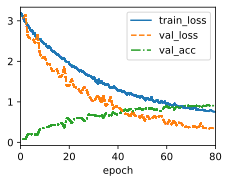

In [ ]:
# Setup the trainer with the desired number of epochs
trainer = d2l.Trainer(max_epochs=30)
# Start training the model with our dataset
trainer.fit(non_linear_model, data_module)

In [ ]:
# Save the models
torch.save(simple_model.state_dict(), "simple_fcnn.pth")
torch.save(non_linear_model.state_dict(), "non_linear_fcnn.pth")

## Checking Accuracy Prior to Attempting to Fine-Tune


In [ ]:
def check_accuracy(data_loader, model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for X, y in data_loader:
            y_hat = model(X)
            predicted = y_hat.argmax(dim=1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return correct / total

In [ ]:
# Check accuracy against the validation set
check_accuracy(validation_loader, non_linear_model)

# Check accuracy against the test set
# check accuracy(test_loader, non_linear_model)

0.033327262793662354

## Attempting to Fine-Tune Using Real World Data

In [ ]:
letter_to_number = {v: k for k, v in label_dict.items()}
small_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
])

def load_images_from_folder(folder_path):
    images = []
    labels = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            img = Image.open(file_path)
            img = small_transform(img)
            images.append(np.array(img))
            labels.append(np.array(letter_to_number[filename[0].upper()]))
        except Exception as e:
            print(f"Error loading image {file_path}: {e}")
    return images, labels

# Note that this RealLifeDatasets folder contains images such as a1.jpeg and so on.
folder_path = "./RealLifeDatasets"
train_images, train_labels = load_images_from_folder(folder_path)

FileNotFoundError: [Errno 2] No such file or directory: './RealLifeDatasets'

In [ ]:
improvement_dataset = ASL(train_images, train_labels, transform=transform_augment)

improvement_loader = DataLoader(improvement_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
# Prepare the dataset for training (Batchsize is 16)
improvement_module = DataModule(improvement_loader, validation_loader)

# Setup the trainer with the desired number of epochs
trainer = d2l.Trainer(max_epochs=50)

# Start trying to fine-tune the model with this separate dataset
trainer.fit(non_linear_model, improvement_module)

## Checking Accuracy Post Fine-Tune

In [ ]:
# Check accuracy against the validation set
check_accuracy(validation_loader, non_linear_model)

# Check accuracy against the test set
# check accuracy(test_loader, non_linear_model)

# Multi-Head CNN Experiment

In [ ]:
transform_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(size=(28, 28), scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

transform_no_augment = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
from PIL import Image

class ASL(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Convert numpy array to PIL image
        image = Image.fromarray(self.images[idx])  # Convert from numpy to PIL
        label = self.labels[idx]

        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
train_dataset = ASL(train_images, train_labels, transform=transform_augment)
validation_dataset = ASL(validation_images, validation_labels, transform=transform_no_augment)
test_dataset = ASL(test_images, test_labels, transform=transform_no_augment)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ASLClassifier(nn.Module):
    def __init__(self, num_classes=26):
        super(ASLClassifier, self).__init__()

        # Convolutional Head 1 - Focusing on hand shapes = larger kernel
        #Try LazyConv2d()
        self.conv_head1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Convolutional Head 2 - focuses on edge with smaller kernel
        self.conv_head2 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Convolutional Head 3 - different dilation
        self.conv_head3 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        fc_input_size = 9408  # equals to observed flattened size

        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )


    def forward(self, x):
        print(f"Input shape: {x.shape}")

        # Get outputs from each head - Me adding debugging so that we know the shapes are coming correctly
        try:
            head1_out = self.conv_head1(x)
            print(f"Head 1 output shape: {head1_out.shape}")
        except Exception as e:
            print(f"Error in Head 1: {e}")
            raise

        try:
            head2_out = self.conv_head2(x)
            print(f"Head 2 output shape: {head2_out.shape}")
        except Exception as e:
            print(f"Error in Head 2: {e}")
            raise

        try:
            head3_out = self.conv_head3(x)
            print(f"Head 3 output shape: {head3_out.shape}")
        except Exception as e:
            print(f"Error in Head 3: {e}")
            raise

        # Concatenate along the channel dimension
        combined = torch.cat((head1_out, head2_out, head3_out), dim=1)
        print(f"Combined shape: {combined.shape}")

        # Flatten
        combined = combined.view(combined.size(0), -1)
        print(f"Flattened shape: {combined.shape}")

    # Forward through fully connected layers
        output = self.fc(combined)
        return output

In [ ]:
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define data augmentations for training
train_transform = transforms.Compose([

    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.unsqueeze(0)),
    transforms.Normalize((0.5,), (0.5,))
])

# Define transforms for validation and test data
test_transform = transforms.Compose([

    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Initialize model, loss function, and optimizer
model = ASLClassifier(num_classes=26).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dynamic learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

def train_model(model, train_loader, validation_loader, criterion, optimizer, scheduler, epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0

        # Training phase
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).long()  # Ensure labels are Long

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Adjust learning rate
        scheduler.step()

        # Store average training loss for this epoch
        train_losses.append(running_loss / len(train_loader))

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in validation_loader:
                images, labels = images.to(device), labels.to(device).long()

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        # Store average validation loss for this epoch
        val_losses.append(val_loss / len(validation_loader))

        # Print epoch statistics
        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {train_losses[-1]:.4f}, "
              f"Validation Loss: {val_losses[-1]:.4f}, "
              f"Validation Accuracy: {100 * correct/total:.2f}%")

    # Plot losses
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs+1), train_losses, label="Train Loss", marker='o')
    plt.plot(range(1, epochs+1), val_losses, label="Validation Loss", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()



In [ ]:
dataset = ASL(train_images, train_labels, transform=train_transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test a batch
for images, labels in loader:
    print(images.shape)
    print(labels.shape)
    break


In [ ]:
train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=20
)


In [ ]:
save_path = '/content/drive/MyDrive/asl_model.pth'
torch.save(model.state_dict(), 'asl_model.pth')

## Fine-Tuning Using Real World Data (Experiment failed due to computation limitation)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive')

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image

class SignLanguageDataset(Dataset):
    def __init__(self, root_dir, label_dict, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_dict = label_dict

        # Iterate over the directories corresponding to each class
        for class_name in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue  # Skip if not a directory

            # Skip hidden directories (if any)
            if class_name.startswith('.'):
                continue

            # Map class name to numeric label
            if class_name in self.label_dict:
                label = self.label_dict[class_name]
            else:
                print(f"Class '{class_name}' not in label_dict. Skipping.")
                continue # Skip classes not in label_dict

            # Collect image paths and labels
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                if img_name.startswith('.'):  # Skip hidden files
                    continue
                self.image_paths.append(img_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("L")  # Convert to grayscale
        if self.transform:
            image = self.transform(image)
        return image, label



class SignLanguageDatasetTest(Dataset):
    def __init__(self, root_dir, label_dict, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_dict = label_dict

        # Iterate over image files in the directory
        for img_name in os.listdir(root_dir):
            img_path = os.path.join(root_dir, img_name)
            if not os.path.isfile(img_path):
                continue  # Skip if not a file

            # Extract the label from the filename
            for label_key in label_dict:
                if label_key in img_name:  # Match part of filename with label_dict keys
                    self.image_paths.append(img_path)
                    self.labels.append(label_dict[label_key])
                    break  # Stop checking after a match

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("L")  # Convert to grayscale
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
from torchvision import transforms

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])



label_dict = {
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7,
    'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15,
    'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22,
    'X': 23, 'Y': 24, 'Z': 25
}


# Load the test dataset
label_dict_test = {
    'A_test': 0, 'B_test': 1, 'C_test': 2, 'D_test': 3, 'E_test': 4, 'F_test': 5, 'G_test': 6, 'H_test': 7,
    'I_test': 8, 'J_test': 9, 'K_test': 10, 'L_test': 11, 'M_test': 12, 'N_test': 13, 'O_test': 14, 'P_test': 15,
    'Q_test': 16, 'R_test': 17, 'S_test': 18, 'T_test': 19, 'U_test': 20, 'V_test': 21, 'W_test': 22,
    'X_test': 23, 'Y_test': 24, 'Z_test': 25,
}

train_dataset = SignLanguageDataset('/content/drive/MyDrive/asl_alphabet_train', label_dict, transform=transform)
test_dataset = SignLanguageDatasetTest('/content/drive/MyDrive/asl_alphabet_test', label_dict_test, transform=transform)

print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")

In [ ]:
# First, let's set up the data loaders with proper batch sizes and splits
from torch.utils.data import random_split
import torch.utils.data as data
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils.data as data
import torchvision.datasets as datasets
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Define batch size and validation split
BATCH_SIZE = 128
VAL_SPLIT = 0.2  # 20% for validation

# Calculate split sizes
train_size = len(train_dataset)
val_size = int(train_size * VAL_SPLIT)
train_size = train_size - val_size

# Split the training dataset into train and validation
train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)

# Create data loaders
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

validation_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

# Print dataset sizes
print(f"Total training samples: {len(train_dataset)}")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_dataset)}")

# Verify data loading
for images, labels in train_loader:
    print(f"Training batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    break

# Check if we're using GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
# Testing a sample batch
for images, labels in train_loader:
    print(f"Image Batch Shape: {images.shape}")
    print(f"Label Batch: {labels}")
    break

In [ ]:
class ASLClassifier(nn.Module):
    def __init__(self, num_classes=26):  # Adjusting for new label size
        super(ASLClassifier, self).__init__()

        self.conv_head1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_head2 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_head3 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully Connected Layers (adjust for 29 classes)
        fc_input_size = 9408
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        head1_out = self.conv_head1(x)
        head2_out = self.conv_head2(x)
        head3_out = self.conv_head3(x)

        combined = torch.cat((head1_out, head2_out, head3_out), dim=1)
        combined = combined.view(combined.size(0), -1)

        output = self.fc(combined)
        return output


In [ ]:
model = ASLClassifier(num_classes=26)

# Load weights only for convolutional layers
pretrained_state_dict = torch.load('/content/drive/MyDrive/asl_model.pth')
model_state_dict = model.state_dict()

# Filter and load only matching keys
pretrained_state_dict = {k: v for k, v in pretrained_state_dict.items() if k in model_state_dict}
model_state_dict.update(pretrained_state_dict)
model.load_state_dict(model_state_dict)

In [ ]:
#freezing the multi head layers to preserve pre-trained feature extraction

for param in model.conv_head1.parameters():
    param.requires_grad = False
for param in model.conv_head2.parameters():
    param.requires_grad = False
for param in model.conv_head3.parameters():
    param.requires_grad = False

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # Increased from 1e-5

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)


In [ ]:
for images, labels in train_loader:
    print(f"Labels: {labels.min()} to {labels.max()}")
    break

In [ ]:
#to check incorrect input shape (tensor dimensions)

for images, labels in train_loader:
    print(f"Image Shape: {images.shape}")
    break


In [ ]:
#Checking invalid data values

for images, labels in train_loader:
    if torch.isnan(images).any() or torch.isinf(images).any():
        print("Invalid values in images")
    if torch.isnan(labels).any() or torch.isinf(labels).any():
        print("Invalid values in labels")
    break


In [ ]:
#label types
for images, labels in train_loader:
    labels = labels.to(torch.long)
    break

In [ ]:
# Add at the start of your script
torch.backends.cudnn.benchmark = True

# Clear GPU cache if needed
if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(f"Total training samples: {len(train_dataset)}")
print(f"Number of batches per epoch: {len(train_loader)}")
print(f"Batch size: {BATCH_SIZE}")

In [ ]:
# Let's try different batch sizes and monitor performance
BATCH_SIZE = 256

# Create data loaders with the new batch size
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

In [ ]:
#Training process

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 2  # Start with a small number of epochs for fine-tuning

for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Adjust learning rate
    scheduler.step()

    # Print epoch statistics
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


## Couldn't go further than this due to Computational Limitations`



In [ ]:
#unfreezing

for param in model.conv_head1.parameters():
    param.requires_grad = True
for param in model.conv_head2.parameters():
    param.requires_grad = True
for param in model.conv_head3.parameters():
    param.requires_grad = True

# Use a lower learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=1e-5)


In [ ]:
#evaluation

model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/fine_tuned_model.pth')
print("Fine-tuned model saved.")

# Validation with Real Life Datasets

In [ ]:
#Fully conected MLP neural network
model = SoftmaxRegressionNonLinear(num_inputs=784, num_outputs=25, lr=0.15)
model.load_state_dict(torch.load("./asl_model_example_epoch80.pth")) #trained parameters

In [ ]:
#Multi-Head CNN Expriment
model = ASLClassifier(num_classes=26).to('cpu')
model.load_state_dict(torch.load("./asl_model.pth")) #trained parameters

In [ ]:
from torchvision import transforms
from PIL import Image, ImageOps

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

In [ ]:
def load_images_from_folder(folder_path):
    images = []
    labels = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            img = Image.open(file_path)
            img = transform(img)
            images.append(img)
            labels.append(filename[0].upper())
        except Exception as e:
            print(f"Error loading image {file_path}: {e}")
    return images, labels

folder_path = "./RealLifeDatasets"
images, labels = load_images_from_folder(folder_path)

class_labels = [chr(i) for i in range(65, 65 + 26)]

predicted_labels = []
correct_count = 0
for idx, (grayscale_image, true_label) in enumerate(zip(images, labels)):
    with torch.no_grad():
        output = model(grayscale_image.unsqueeze(0))
        predicted_class = torch.argmax(output, 1).item()
        predicted_label = class_labels[predicted_class]
        predicted_labels.append(predicted_label)
        is_correct = predicted_label == true_label
        correct_count += is_correct
        print(f"Image {idx + 1}: Predicted Class: {predicted_label}, True Label: {true_label}, Correct: {is_correct}")

accuracy = correct_count / len(images) * 100 if images else 0
print(f"Accuracy: {accuracy:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

correct_counts = {label: 0 for label in class_labels}
for true_label, predicted_label in zip(labels, predicted_labels):
    if true_label == predicted_label:
        correct_counts[true_label] += 1

plt.bar(correct_counts.keys(), correct_counts.values())
plt.xlabel('Alphabets')
plt.ylabel('Correct Predictions')
plt.title('Correct Predictions per Alphabet')
plt.show()

In [ ]:
def display_alphabet_grid(images, labels, predicted_labels, rows=4, cols=6):
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12), dpi=120)
    fig.subplots_adjust(hspace=1.8, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            image = images[i].squeeze(0).numpy()
            true_label = labels[i]
            predicted_label = predicted_labels[i]
            color = 'green' if true_label == predicted_label else 'red'

            ax.imshow(image, cmap='gray', interpolation='nearest')
            ax.axis('off')


            bbox_props = dict(boxstyle="round,pad=0.3", edgecolor=color, facecolor="white", lw=1)
            ax.text(
                0.5, -0.2, f"Actual: {true_label}\nPredicted: {predicted_label}",
                fontsize=10, ha='center', va='center', color=color, bbox=bbox_props, transform=ax.transAxes)
        else:
            ax.axis('off')

    plt.suptitle("Alphabet Classification Results", fontsize=24, fontweight='bold', color='darkblue', y=0.98)
    plt.tight_layout(rect=[0, 0.3, 1, 0.95])
    plt.show()

def sort_data_alphabetically(images, labels, predicted_labels):
    combined = list(zip(labels, images, predicted_labels))
    combined.sort(key=lambda x: x[0])
    sorted_labels, sorted_images, sorted_predictions = zip(*combined)
    return list(sorted_images), list(sorted_labels), list(sorted_predictions)

def extract_specific_indices(images, labels, predicted_labels):
    indices = [i for i in range(len(labels)) if (i % 4 == 0)]
    return [images[i] for i in indices], [labels[i] for i in indices], [predicted_labels[i] for i in indices]

images_sorted, labels_sorted, predicted_labels_sorted = sort_data_alphabetically(
    images, labels, predicted_labels
)

images_filtered, labels_filtered, predicted_labels_filtered = extract_specific_indices(
    images_sorted, labels_sorted, predicted_labels_sorted
)

display_alphabet_grid(images_filtered, labels_filtered, predicted_labels_filtered)


<br>
<hr>